In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Source
Social media vs Productivity

La Data es obtenido desde Kaggle. El siguiente comando obtiene la data y almacena en formato csv : 
- kaggle datasets download -d mahdimashayekhi/social-media-vs-productivity -p social_media_productivity --unzip

# Data Understanding

¿Qué espero encontrar?

* Tengo dos compañeras en mi universidad que pertenecen a distintos programas, la compañera A pertenece al área de medicina y la compañera B pertenece a una carrera de TI.
Ambas se encuentran en los últimos semestres de sus carreras, y ambas tienen malos hábitos de sueño (duermen tarde y se despiertan temprano)
En base a estos datos pretendo descubrir qué relación existe entre las horas que cada persona desde su tipo de trabajo 
    - ¿Cómo afecta la falta de sueño (sleep_hours) a la productividad real (actual_productivity_score) en sectores de alta presión como Salud vs. Tecnología (job_type)?

* ¿En las carreras de TI al estar más expuestos a los dispositivos tecnológicos existe una mayor cantidad de estrés en comparación con personas desempleadas que no tienen que estar usando dispositivos tecnológicos por obligación?
    - ¿El personal de TI presenta menores horas de desconexión semanal (weekly_offline_hours) y mayores niveles de estrés (stress_level) en comparación con perfiles no tecnológicos o desempleados?

* Las personas que tienen mayor cantidad de pausas activas tienen menor nivel estrés y por consiguiente mejor satisfacción en su empleo?
    - ¿Existe una correlación positiva entre la cantidad de descansos (breaks_during_work) y la satisfacción laboral (job_satisfaction_score)? ¿Actúan los descansos como un mitigador del estrés?



**Hipótesis Iniciales a Validar**

H1 (Ocupación y Sueño): Los profesionales en sectores tecnológicos y de salud experimentan un impacto distinto en su productividad real ante la privación de sueño.

H2 (Tecnológicas vs. Desconexión): Los roles vinculados a TI tienen menores índices de horas offline semanales, lo que se traduce en niveles de estrés más agudos.

H3 (El efecto descanso): Un mayor volumen de pausas diarias se asocia con menores niveles de estrés y un incremento en la satisfacción laboral.




In [2]:
def get_data() :
    df = pd.read_csv('social_media_vs_productivity.csv')
    return df

|   **Nombre de la columna**          |	                        **Descripción**                                     |
| -------------------- | -------------------------------------------------------------------------------------- |
|   age                           |	    Edad del individuo (18–65 años)                                             |
|   gender                        |   	Identidad de género: Masculino, Femenino u Otro                             |
|   job_type	                  |     Sector o situación laboral (TI, Educación, Estudiante, etc.)                |
|   daily_social_media_time       |	    Tiempo promedio diario dedicado a las redes sociales (horas)                |
|   social_platform_preference	  |     Plataforma social más utilizada (Instagram, TikTok, Telegram, etc.)         |
|   number_of_notifications	      |     Número de notificaciones móviles/sociales por día   |
|   work_hours_per_day	          |     Promedio de horas trabajadas cada día   |
|   perceived_productivity_score  |	    Puntuación de productividad autoevaluada (escala: 0–10) |
|   actual_productivity_score     |    	Puntuación de productividad simulada real (escala: 0–10)    |
|   stress_level	              |     Nivel de estrés actual (escala: 1–10)   |
|   sleep_hours	                  |     Horas promedio de sueño por noche
|   screen_time_before_sleep	  |     Tiempo dedicado a las pantallas antes de dormir (horas) |
|   breaks_during_work	          |     Número de descansos tomados durante las horas de trabajo
|   uses_focus_apps	              |     Si el usuario utiliza aplicaciones de enfoque digital (Verdadero/Falso) |
|   has_digital_wellbeing_enabled |	    ¿Está activado el Bienestar Digital? (Verdadero/Falso)  |
|   coffee_consumption_per_day	  |     Número de tazas de café consumidas al día   |
|   days_feeling_burnout_per_month|	    Número de días de agotamiento laboral reportados por mes    |
|   weekly_offline_hours	      |     Total de horas que se pasan desconectados cada semana (sin incluir el sueño)    |
|   job_satisfaction_score	      |     Satisfacción con las responsabilidades laborales y personales (escala: 0-10)    |

In [3]:
df = get_data()

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

# EDA
Análisis exploratorio de datos

## Dimensiones de la calidad de datos :
- Completitud
- Validez
- Completitud

## Completitud :

El dataset cuenta con 30.000 registros en el mejor de los casos, sin embargo hay columnas que no tienen todos los registros como :

daily_social_media_time, perceived_productivity_score, actual_productivity_score, stress_level, sleep_hours, screen_time_before_sleep y job_satisfaction_score


In [4]:
columns_incomplete = df.columns[df.isnull().any()] # Identificar columnas que tienen valores faltantes
# print(columns_incomplete)

for column in columns_incomplete:
    missing_percentage = df[column].isna().mean() * 100
    print(f'- "{column}" Porcentaje de datos faltantes: {missing_percentage: .2f}%')

- "daily_social_media_time" Porcentaje de datos faltantes:  9.22%
- "perceived_productivity_score" Porcentaje de datos faltantes:  5.38%
- "actual_productivity_score" Porcentaje de datos faltantes:  7.88%
- "stress_level" Porcentaje de datos faltantes:  6.35%
- "sleep_hours" Porcentaje de datos faltantes:  8.66%
- "screen_time_before_sleep" Porcentaje de datos faltantes:  7.37%
- "job_satisfaction_score" Porcentaje de datos faltantes:  9.10%


| % de datos faltantes | Interpretación común                                                                   |
| -------------------- | -------------------------------------------------------------------------------------- |
| 0% - 5%              | Generalmente no es un problema.                                                        |
| 5% - 20%             | Requiere atención, pero suele ser recuperable con imputación.                          |
| 20% - 40%            | Ya es una cantidad importante; hay que evaluar si la variable aporta suficiente valor. |
| 40% - 60%            | Muchas veces se considera candidata a eliminarse.                                      |
| > 60%                | Frecuentemente se descarta, salvo que sea una variable muy relevante para el negocio.  |
| > 80%                | Normalmente se elimina.                                                                |


In [5]:
for col in columns_incomplete:
    print(f'\n{col}')

    porcentaje = (
        df.groupby('job_type')[col]
          .apply(lambda x: x.isna().mean() * 100)
          .sort_values(ascending=False)
    )

    print(porcentaje)


daily_social_media_time
job_type
IT            9.629924
Finance       9.388081
Education     9.179031
Health        9.164639
Unemployed    9.156918
Student       8.778931
Name: daily_social_media_time, dtype: float64

perceived_productivity_score
job_type
IT            5.670513
Health        5.474453
Education     5.459941
Unemployed    5.304558
Student       5.187550
Finance       5.182380
Name: perceived_productivity_score, dtype: float64

actual_productivity_score
job_type
Unemployed    8.128278
IT            8.117788
Health        7.948094
Student       7.901038
Education     7.675569
Finance       7.534383
Name: actual_productivity_score, dtype: float64

stress_level
job_type
IT            7.003581
Health        6.751825
Student       6.264964
Unemployed    6.192013
Education     6.092977
Finance       5.780347
Name: stress_level, dtype: float64

sleep_hours
job_type
Student       9.158021
Education     9.020772
IT            8.834063
Unemployed    8.390480
Finance       8.291808

In [6]:
for col in columns_incomplete:
    print(f'\nProporción de datos faltantes en {col}: por cada tipo de empleo ',df[df[col].isna()]['job_type'].value_counts())


Proporción de datos faltantes en daily_social_media_time: por cada tipo de empleo  job_type
IT            484
Finance       471
Education     464
Unemployed    454
Health        452
Student       440
Name: count, dtype: int64

Proporción de datos faltantes en perceived_productivity_score: por cada tipo de empleo  job_type
IT            285
Education     276
Health        270
Unemployed    263
Finance       260
Student       260
Name: count, dtype: int64

Proporción de datos faltantes en actual_productivity_score: por cada tipo de empleo  job_type
IT            408
Unemployed    403
Student       396
Health        392
Education     388
Finance       378
Name: count, dtype: int64

Proporción de datos faltantes en stress_level: por cada tipo de empleo  job_type
IT            352
Health        333
Student       314
Education     308
Unemployed    307
Finance       290
Name: count, dtype: int64

Proporción de datos faltantes en sleep_hours: por cada tipo de empleo  job_type
Student       4

### Distribución de los datos

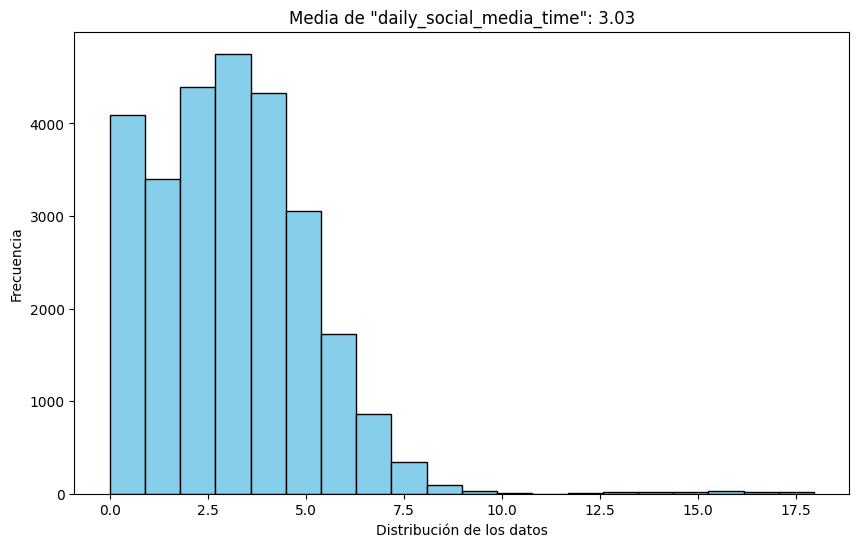

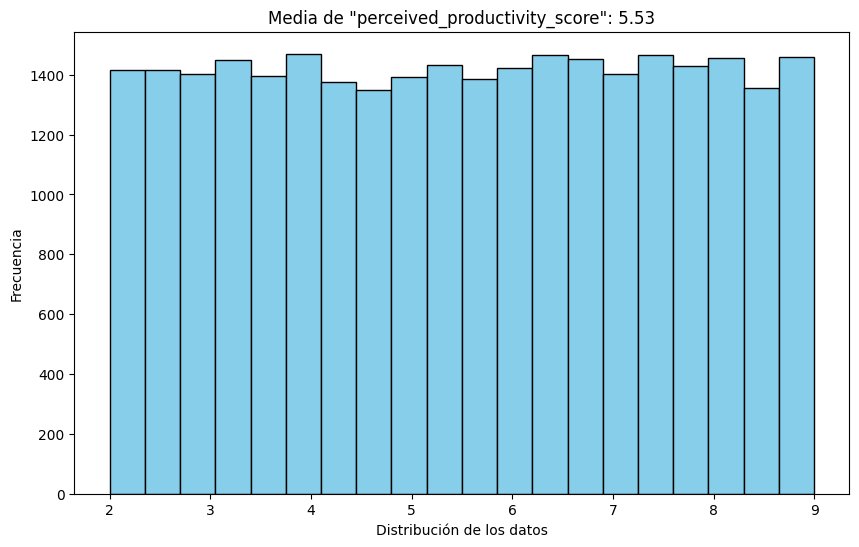

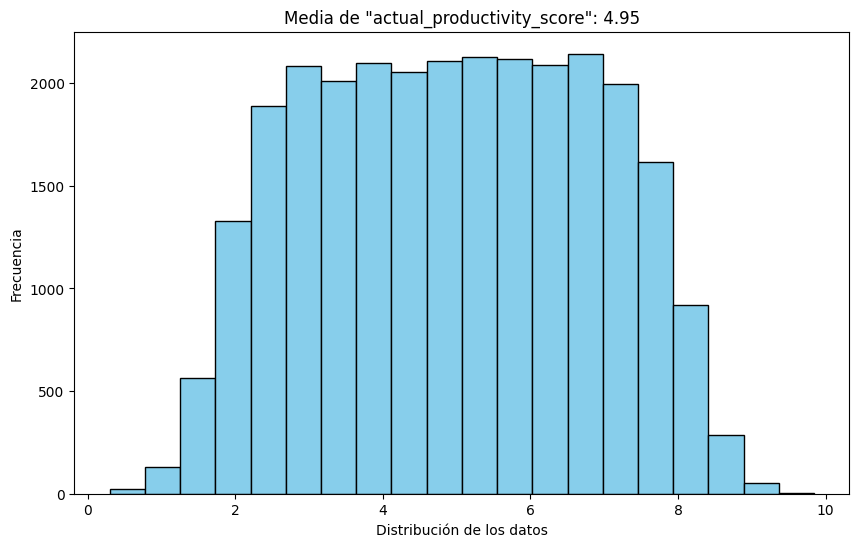

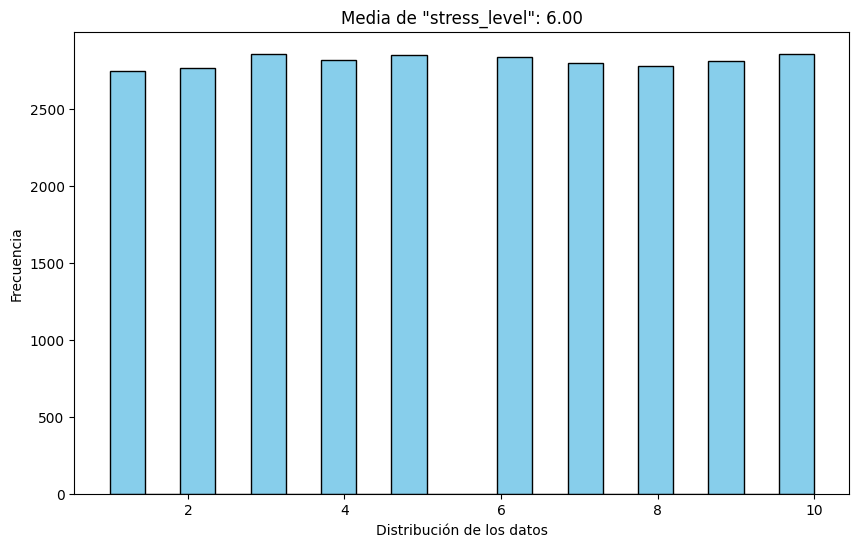

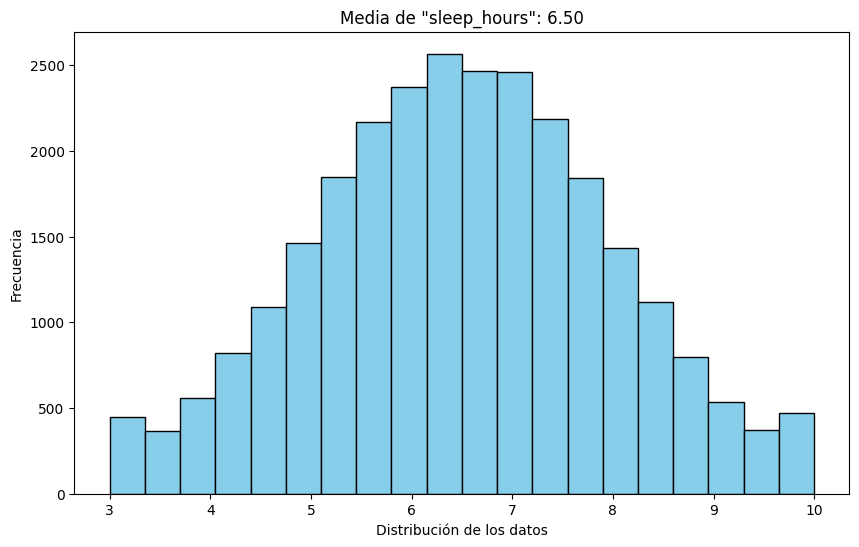

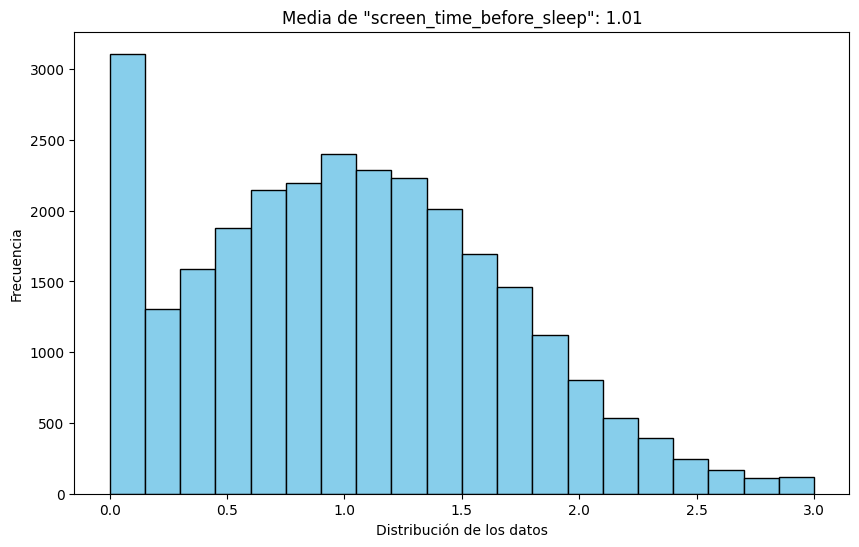

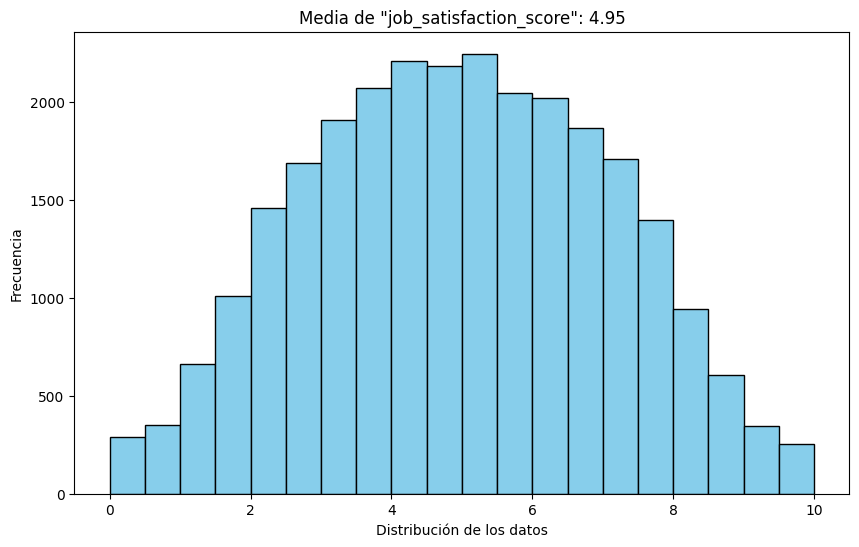

In [7]:
# Distribución de daily_social_media_time
for column in columns_incomplete:
    plt.figure(figsize=(10, 6))
    plt.hist(df[column], bins = 20, color= 'skyblue', edgecolor='black')
    plt.xlabel('Distribución de los datos')
    plt.ylabel('Frecuencia')
    plt.title(f'Media de "{column}": {df[column].median():.2f}')
    plt.show()

### Rellenando datos faltantes

Considerando que el porcentaje de datos faltantes para las columnas es muy bajo podemos tomar dos alternativas:
1. Eliminación con Justificación (Dropping) : Considerando que se tiene un dataset robusto de 30.000 filas, por lo que perder alrededor de 2,730 registros representa menos del 10% de los datos
2. Llenado de datos usando mean: Después de analizar la distribución de las columnas faltantes para identificar un patrón normal o con poco ruido se puede rellenar los datos usando mediana.

La decisión elegida en este caso es la de rellenar estos datos faltantes usando mediana según el comportamiento que presenta cada tipo de trabajo debido a que probablemente:
* Un estudiante duerme distinto a alguien en finanzas
* El tiempo en redes sociales puede variar por ocupación.
* La satisfacción laboral puede depender fuertemente al tipo de empleo.

In [8]:
for col in columns_incomplete:
    df[col] = (
        df.groupby('job_type')[col]
          .transform(lambda x: x.fillna(x.median()))
    )

### Visualización Posterior al relleno de datos 

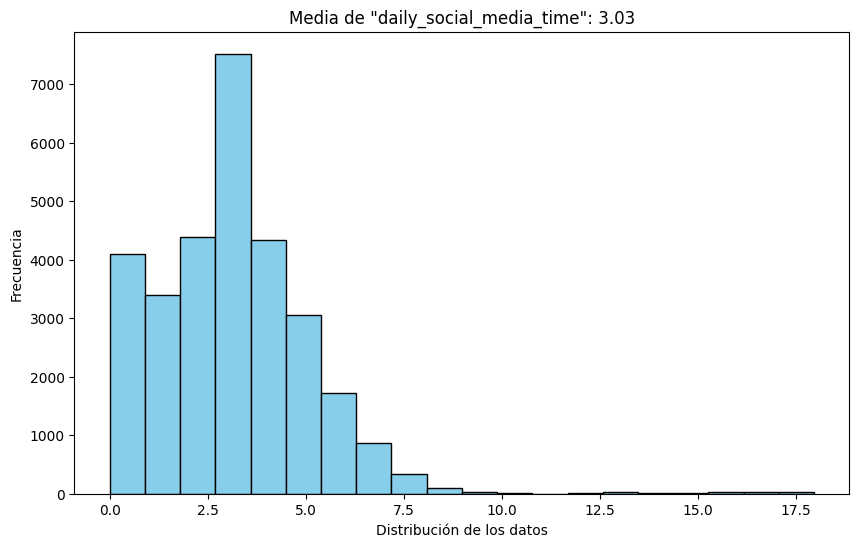

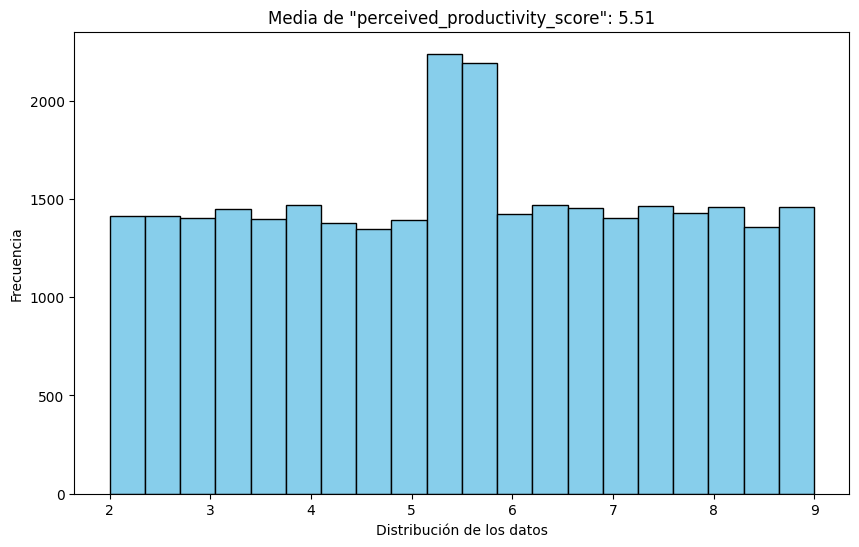

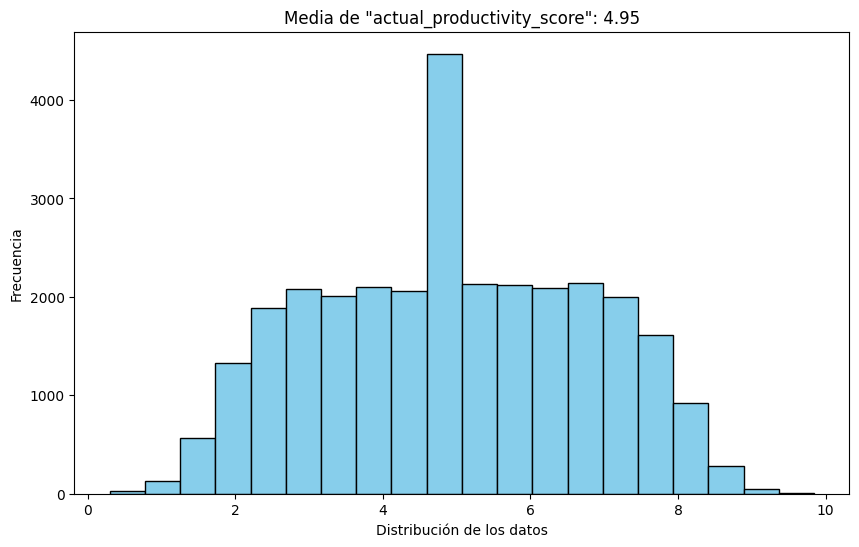

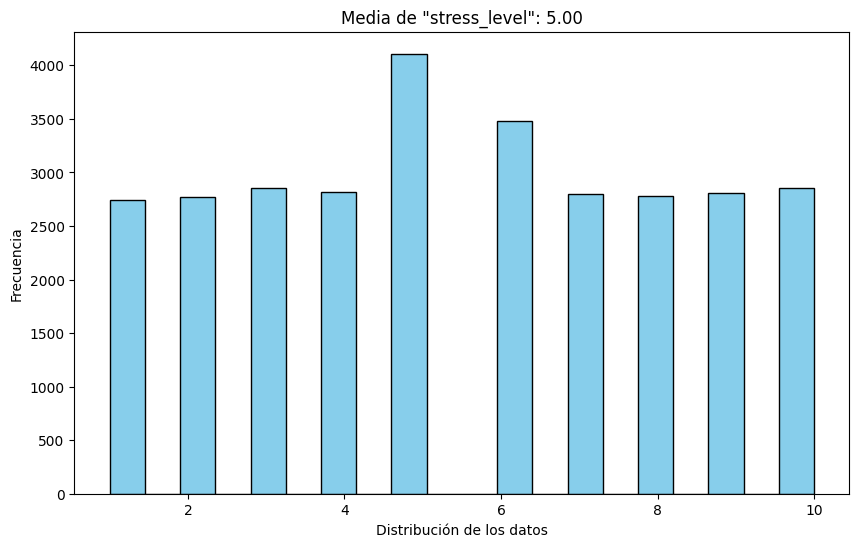

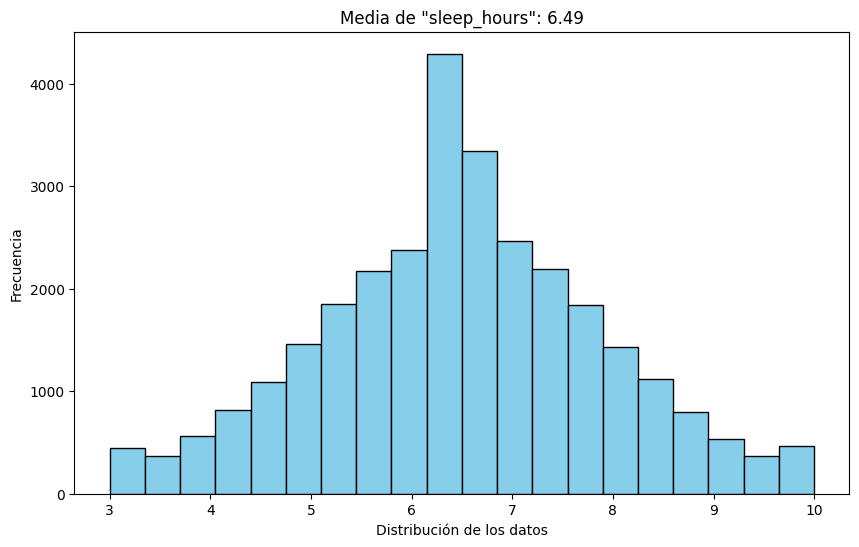

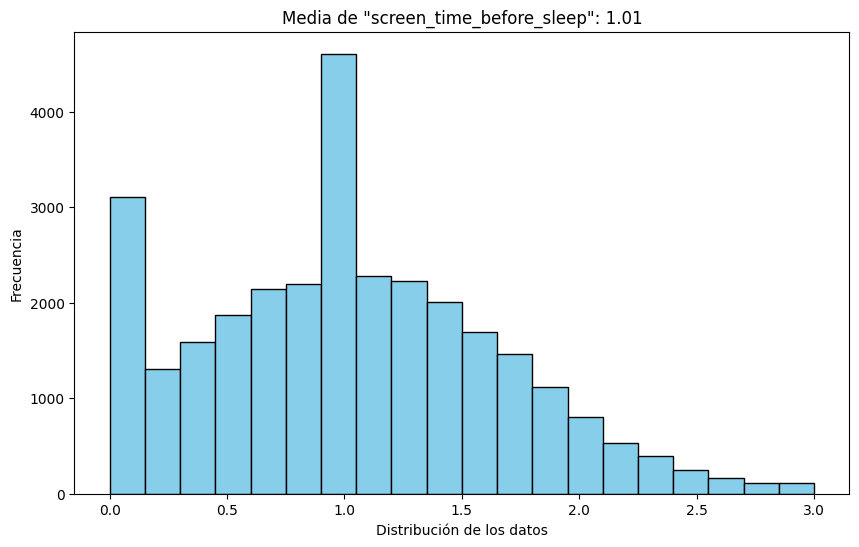

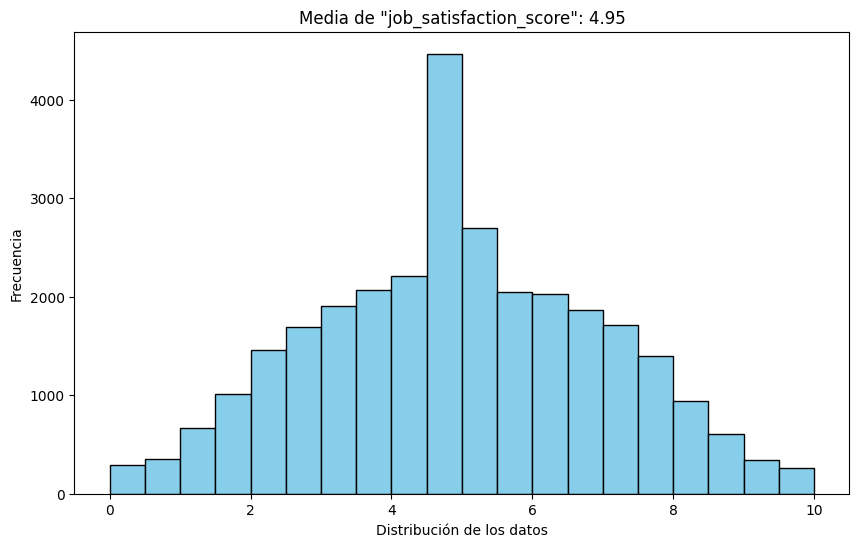

In [9]:
# Distribución de daily_social_media_time
for column in columns_incomplete:
    plt.figure(figsize=(10, 6))
    plt.hist(df[column], bins = 20, color= 'skyblue', edgecolor='black')
    plt.xlabel('Distribución de los datos')
    plt.ylabel('Frecuencia')
    plt.title(f'Media de "{column}": {df[column].median():.2f}')
    plt.show()

### **¿Funcionó correctamente?** 
No. Al rellenar casi 3,000 datos faltantes con un único valor constante (la mediana general, por ejemplo para la columna 'job_satisfaction_score' que ronda el 5), lo que ocurrió fue concentrar artificialmente toda la variabilidad en un solo punto que es el pico visual que se observa en el centro.

En estadística, esto se llama **reducir la varianza**. Lo que causa desfigurar la distribución natural "de campana" que tenían los datos en su inicio y se crea un sesgo. Si se usan estos datos así para entrenar un modelo o sacar conclusiones, se estarían obteniendo conclusiones poco verdaderas como que una enorme cantidad de personas tienen una satisfacción exactamente de 5 y esto fue ajustado por el código, probablemente alejandose de la realidad.

### PLAN B: Imputación Avanzada / Predictiva (K-NN o Algoritmos) para tratar de obtener un mejor resultado

KNN Imputer (K-Nearest Neighbors) no inventa un número al azar ni usa un promedio general. Lo que hace es buscar a los *K* "vecinos" (registros o personas) más parecidos al usuario que tiene el dato faltante, basándose en el resto de las columnas (como su edad, sus horas de sueño o su nivel de estrés). Una vez que encuentra a esos "gemelos laborales", promedia sus puntuaciones de satisfacción y rellena el vacío.


El algoritmo de KNN solo entiende de números y distancias métricas. No sabe medir la "distancia" entre la palabra "Medicina" y "TI" en la columna job_type.
- ¿Lo mejor sería excluir temporalmente las columnas categóricas (object) para la imputación, o se va a transformar en números (usando técnicas como One-Hot Encoding) para que el algoritmo también pueda usarlas como criterio de similitud? 
- ¿ Cuántos vecinos K trabajar por defecto? la librería de Scikit-Learn suele usar $K=5$ vecinos.El paso a seguir: Pensar si 5 es suficiente para un dataset de 30,000 registros, o si un número ligeramente mayor (como 10 or 15) podría darle más estabilidad al promedio sin perder la esencia de la "cercanía".

In [10]:
df = get_data()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

**¿Qué columnas numéricas tienen un valor real para predecir la satisfacción laboral?**

Las siguientes columnas pueden tener una relación con la satisfacción laboral:

'age' : Es posible que la edad tenga una fuerte relación con la satisfacción laboral, en el sentido en que las personas mayores al tener una mayor trayectoria, mayor madurez y mayor experiencia pueden tener puestos donde las personas se sientan más satisfechos con su vida y por consecuencia, con su satisfacción laboral.

'job_type': Las personas que comparten un tipo de empleo, si este empleo fue elegido por convicción, pueden demostrar una relación entre sí, su forma de ver la vida, sus comportamientos, su tiempo de uso de dispositivos tecnológicos, entre otros.

'gender': El género también puede tener una relación con la satisfacción laboral, incluso el desempleo puede tener relación con el género.

'uses_focus_apps' y 'weekly_offline_hours' : Las notificaciones encendidas puede tener mayor exposición al estrés, cada vez que una notificación suena genera una respuesta inmediata en el cuerpo que puede ser entendida como ansiedad o estrés, además la cantidad de horas de desconexión, a menor cantidad de horas existe mayor exposición a dispositivos tecnológicos y por ende mayor probabilidad de estrés.

'days_feeling_burnout_per_month' (Días de burnout): Si alguien siente agotamiento extremo varios días al mes, su satisfacción laboral estará por el suelo. Es un dato crucial para que KNN encuentre "vecinos" en la misma situación emocional.

In [11]:
columns_incomplete

Index(['daily_social_media_time', 'perceived_productivity_score',
       'actual_productivity_score', 'stress_level', 'sleep_hours',
       'screen_time_before_sleep', 'job_satisfaction_score'],
      dtype='object')

In [12]:
# KNNImputer
from sklearn.impute import KNNImputer
                                                                                              
df_knn = df[['age','job_type','gender', 'uses_focus_apps', 'days_feeling_burnout_per_month',
             'daily_social_media_time', 'perceived_productivity_score','actual_productivity_score', # Columna a imputar
             'stress_level', 'sleep_hours','screen_time_before_sleep', 'job_satisfaction_score']]
df_knn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   job_type                        30000 non-null  object 
 2   gender                          30000 non-null  object 
 3   uses_focus_apps                 30000 non-null  bool   
 4   days_feeling_burnout_per_month  30000 non-null  int64  
 5   daily_social_media_time         27235 non-null  float64
 6   perceived_productivity_score    28386 non-null  float64
 7   actual_productivity_score       27635 non-null  float64
 8   stress_level                    28096 non-null  float64
 9   sleep_hours                     27402 non-null  float64
 10  screen_time_before_sleep        27789 non-null  float64
 11  job_satisfaction_score          27270 non-null  float64
dtypes: bool(1), float64(7), int64(2)

In [13]:
# Transformación: Aplicas One-Hot Encoding a job_type y gender.
df_knn = pd.get_dummies(df_knn, columns=['job_type', 'gender'])
df_knn.info()

# Reemplazar true por 1 y False por 0 en las columnas dummies
cols_booleanas = ['job_type_Education', 'job_type_Finance','job_type_Health','job_type_IT', 'job_type_Student', 'job_type_Unemployed',
       'gender_Female', 'gender_Male', 'gender_Other']

for col in cols_booleanas:
    df_knn[col] = df_knn[col].astype(int)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   uses_focus_apps                 30000 non-null  bool   
 2   days_feeling_burnout_per_month  30000 non-null  int64  
 3   daily_social_media_time         27235 non-null  float64
 4   perceived_productivity_score    28386 non-null  float64
 5   actual_productivity_score       27635 non-null  float64
 6   stress_level                    28096 non-null  float64
 7   sleep_hours                     27402 non-null  float64
 8   screen_time_before_sleep        27789 non-null  float64
 9   job_satisfaction_score          27270 non-null  float64
 10  job_type_Education              30000 non-null  bool   
 11  job_type_Finance                30000 non-null  bool   
 12  job_type_Health                 

#### Escalamiento: Se debe aplicar un escalador a todo el dataframe para normalizar las distancias.

Al analizar los rangos de los datos actuales tras el procesamiento:

Las columnas de job_type, uses_focus_apps y gender ahora valen 0 o 1. (como Booleano/Entero)

Sin embargo: 'days_feeling_burnout_per_month' puede ir de 0 a 30 o 'age' puede ir de 18 a 65 o más.

Problema: Como KNN calcula la distancia geométrica (pitagórica) entre personas, para el algoritmo una diferencia de 20 años de edad va a pesar 20 veces más que la diferencia entre ser de TI o de Medicina (que es solo 1). La edad y los días de burnout van a "aplastar" por completo a las variables categóricas y booleanas.

Solución conceptual: Antes de aplicar el KNNImputer, se deben pasar los datos por un escalador (como MinMaxScaler de Scikit-Learn) para que absolutamente todas las columnas queden atrapadas en un rango de 0 a 1. Así, un año de edad pesará proporcionalmente lo mismo que un cambio de carrera.

In [14]:
# Escalamiento: Se debe aplicar un escalador a todo el dataframe para normalizar las distancias.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_knn_scaled = pd.DataFrame(scaler.fit_transform(df_knn), columns=df_knn.columns)

imputer = KNNImputer(n_neighbors=40)
df_knn_imputed = pd.DataFrame(imputer.fit_transform(df_knn_scaled), columns=df_knn_scaled.columns)

# 2. Des-escalamos inmediatamente usando el scaler original
datos_desescalados = scaler.inverse_transform(df_knn_imputed)

# 3. Lo convertimos de vuelta a un DataFrame limpio con los valores en su escala original
df_final = pd.DataFrame(datos_desescalados, columns=df_knn.columns)

Revertir el One-Hot Encoding (De Dummies a Texto)

In [15]:
# Definimos cuáles eran las columnas que pertenecían a job_type
cols_job = ['job_type_Education', 'job_type_Finance', 'job_type_Health', 
            'job_type_IT', 'job_type_Student', 'job_type_Unemployed']

# Buscamos cuál columna tiene el valor más alto para cada fila
df_final['job_type'] = df_final[cols_job].idxmax(axis=1)

# Limpiamos el texto borrando el prefijo "job_type_" para que quede solo la categoría
df_final['job_type'] = df_final['job_type'].str.replace('job_type_', '')

In [16]:
# Repetimos el proceso exacto para el género
cols_gender = ['gender_Female', 'gender_Male', 'gender_Other']

df_final['gender'] = df_final[cols_gender].idxmax(axis=1)
df_final['gender'] = df_final['gender'].str.replace('gender_', '')

In [17]:
# Eliminamos todas las columnas dummies del dataframe procesado
columnas_a_eliminar = cols_job + cols_gender
df_final = df_final.drop(columns=columnas_a_eliminar)

# Opcional: Redondear las columnas que deberían ser enteros (como la edad o los días de burnout)
columnas_enteras = ['age', 'days_feeling_burnout_per_month']
df_final[columnas_enteras] = df_final[columnas_enteras].round().astype(int)

In [18]:
# 1. Creamos una copia del dataframe original para no dañarlo
df_cleaned = df.copy()

# 2. Reemplazamos las 12 columnas viejas con las 12 columnas completamente limpias de df_final
df_cleaned[df_final.columns] = df_final

# 3. Verificamos que tengamos las 19 columnas de vuelta y 0 nulos
print(df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         30000 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    30000 non-null  float64
 8   actual_productivity_score       30000 non-null  float64
 9   stress_level                    30000 non-null  float64
 10  sleep_hours                     30000 non-null  float64
 11  screen_time_before_sleep        30000 non-null  float64
 12  breaks_during_work              

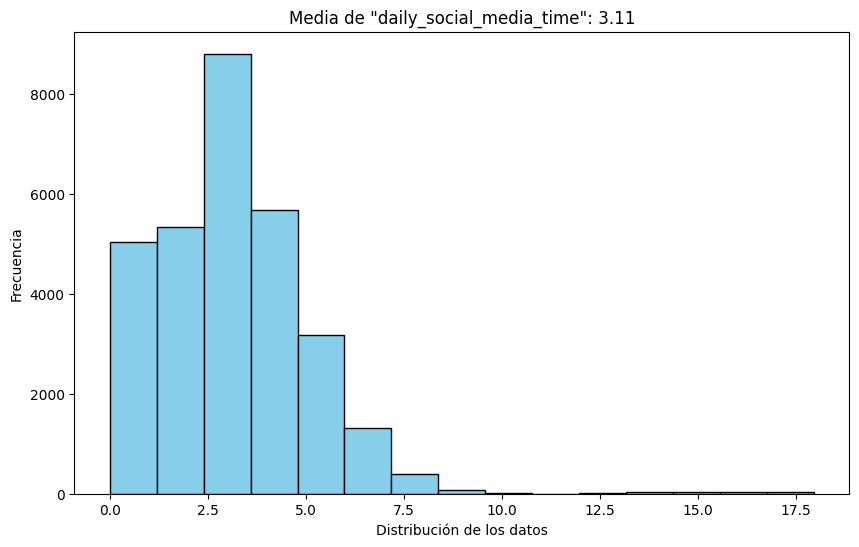

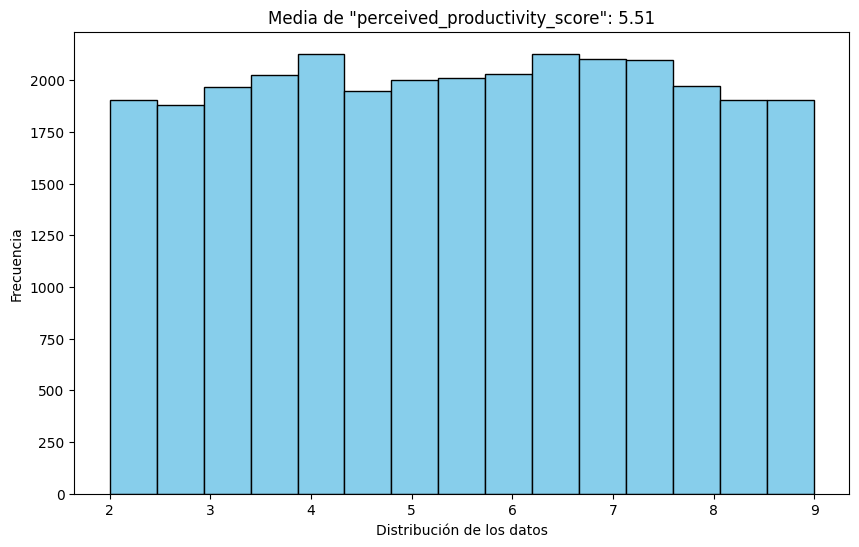

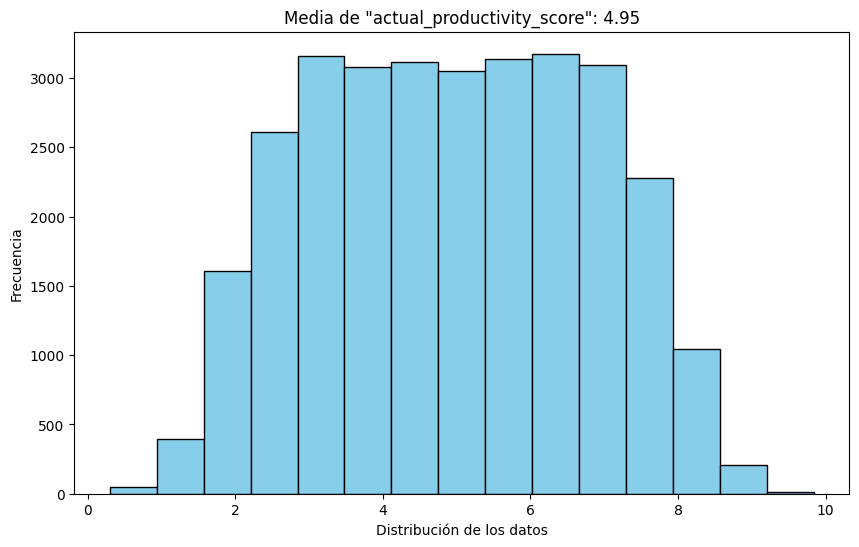

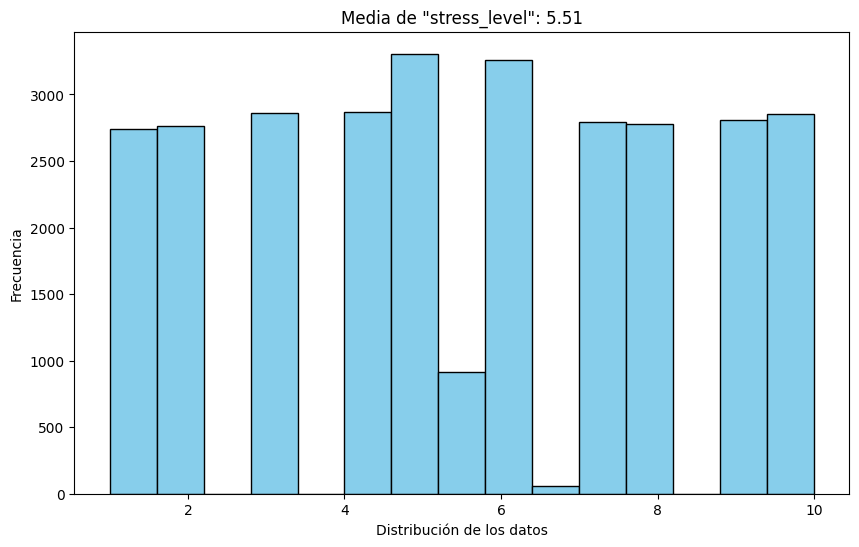

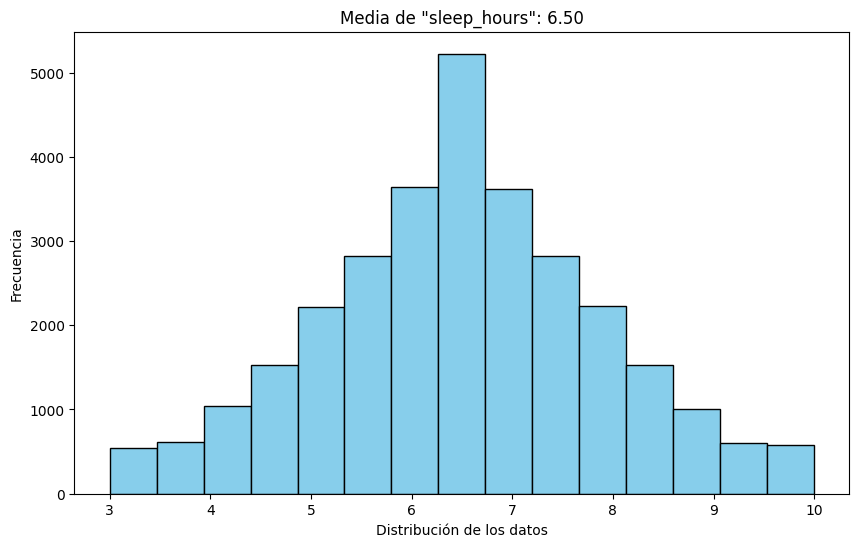

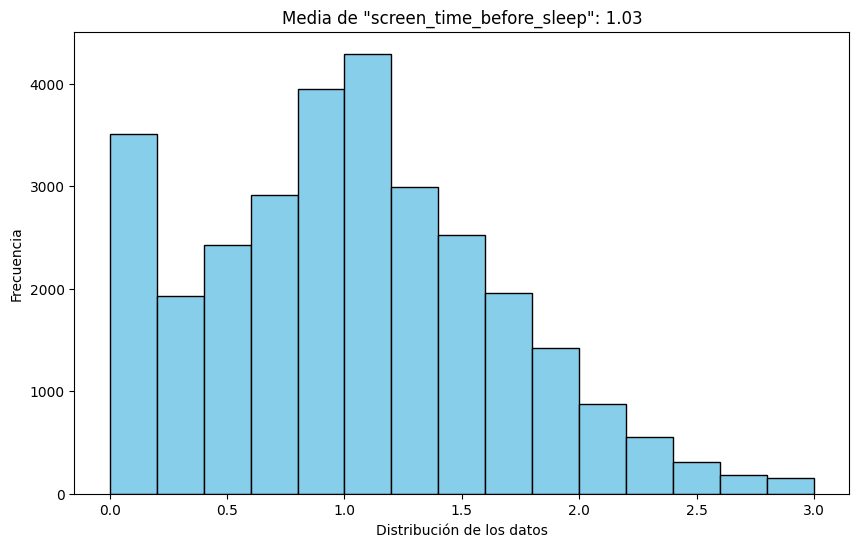

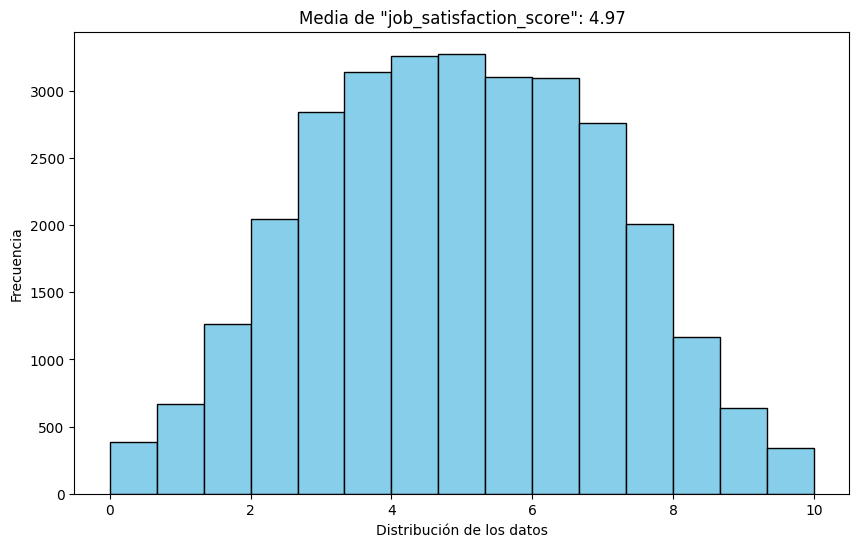

In [19]:
for column in columns_incomplete:
    plt.figure(figsize=(10, 6))
    plt.hist(df_cleaned[column], bins = 15, color= 'skyblue', edgecolor='black')
    plt.xlabel('Distribución de los datos')
    plt.ylabel('Frecuencia')
    plt.title(f'Media de "{column}": {df_cleaned[column].mean():.2f}')
    plt.show()

**Conclusión** : Este resultado es notablemente más aceptable , podemos ver que no hay deformaciones tan pronunciadas sobre la distribución de los datos como sí ocurrió con el primer método de llenado de null por la mediana.

In [20]:
df_cleaned.columns

Index(['age', 'gender', 'job_type', 'daily_social_media_time',
       'social_platform_preference', 'number_of_notifications',
       'work_hours_per_day', 'perceived_productivity_score',
       'actual_productivity_score', 'stress_level', 'sleep_hours',
       'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps',
       'has_digital_wellbeing_enabled', 'coffee_consumption_per_day',
       'days_feeling_burnout_per_month', 'weekly_offline_hours',
       'job_satisfaction_score'],
      dtype='object')

In [21]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         30000 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    30000 non-null  float64
 8   actual_productivity_score       30000 non-null  float64
 9   stress_level                    30000 non-null  float64
 10  sleep_hours                     30000 non-null  float64
 11  screen_time_before_sleep        30000 non-null  float64
 12  breaks_during_work              

In [22]:
df_cleaned

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,0.0,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,1.0,True,2,25,0.000000,3.412427
2,32,Male,Finance,3.068000,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,1.0,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,3.182360,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,0.0,False,0,4,23.876616,1.733670
4,25,Male,IT,3.036333,Telegram,66,6.214096,8.868753,7.097253,7.0,5.405706,1.876254,1,0.0,True,1,30,10.653519,9.693060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,34,Female,Health,1.877297,Facebook,59,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9,0.0,False,4,5,21.776927,3.271412
29996,39,Male,Health,4.437784,Instagram,46,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3,0.0,False,1,29,4.111370,6.155613
29997,42,Male,Education,17.724981,TikTok,64,10.915036,8.611005,8.658912,5.0,5.491520,1.224296,10,0.0,False,1,2,1.888315,6.285237
29998,20,Female,Education,3.796634,Instagram,56,6.937410,7.767076,6.895583,8.0,6.816069,0.234483,1,0.0,False,2,9,12.511871,7.854711


## Validez :

¿Las variables numéricas tienen límites lógicos? Por ejemplo: ¿Hay personas con más de 24 horas en work_hours_per_day? 

¿Los scores de productividad y satisfacción están en la misma escala (ej. de 1 a 10 o de 1 a 100)? ¿Hay edades negativas o de 150 años?

Propósito: Identificación de Outliers

In [23]:
df = df_cleaned.copy()

print('Empleos con horas de trabajo mayor o igual a 12 horas por día:')
df.query('work_hours_per_day >= 12')[['job_type','work_hours_per_day']].drop_duplicates().head()

Empleos con horas de trabajo mayor o igual a 12 horas por día:


,job_type,work_hours_per_day
444,Health,12.0
547,Student,12.0
1293,IT,12.0
2612,Unemployed,12.0
2800,Finance,12.0


In [24]:
print('Registros con puntaje de productividad actual superior a 10:', df.query('actual_productivity_score > 10').shape[0])

print('Registros con puntaje desatisfacción de empleos superior a 10:',df.query('job_satisfaction_score > 10').shape[0])

# print('Registros con niveles de estrés superior a 10:',df.query('stress_level > 10').shape[0])
print('Rango mínimo de estrés:',df['stress_level'].min() , 'Rango máximo de estrés:',df['stress_level'].max())

print('Edad máxima de registros:', df['age'].max())

print(df['social_platform_preference'].unique())

print('Registros con sensación de agotamiento mayor o igual a 31 días: ',df.query('days_feeling_burnout_per_month >= 31')['days_feeling_burnout_per_month'].unique())

print(df['uses_focus_apps'].unique())

Registros con puntaje de productividad actual superior a 10: 0
Registros con puntaje desatisfacción de empleos superior a 10: 0
Rango mínimo de estrés: 1.0 Rango máximo de estrés: 10.0
Edad máxima de registros: 65
['Facebook' 'Twitter' 'Telegram' 'TikTok' 'Instagram']
Registros con sensación de agotamiento mayor o igual a 31 días:  [31]
[0. 1.]


In [25]:
df['uses_focus_apps'] = df['uses_focus_apps'].astype(int)
df['uses_focus_apps'] = df['uses_focus_apps'].astype(bool)

## Consistencia :

Si alguien tiene uses_focus_apps en False, ¿tiene lógica que sus notificaciones sean cero?


In [26]:
df[df['uses_focus_apps'] == False]['number_of_notifications'].shape # unique()

(20979,)

## Unicidad :

¿Hay filas idénticas (duplicados exactos)?

Por qué importa: En una base de datos de 30,000 registros, tener filas repetidas puede inflar artificialmente las conclusiones.

In [27]:
df = df.drop_duplicates()
df.shape

(30000, 19)

## Distribución de datos

### Distribución variables categóricas

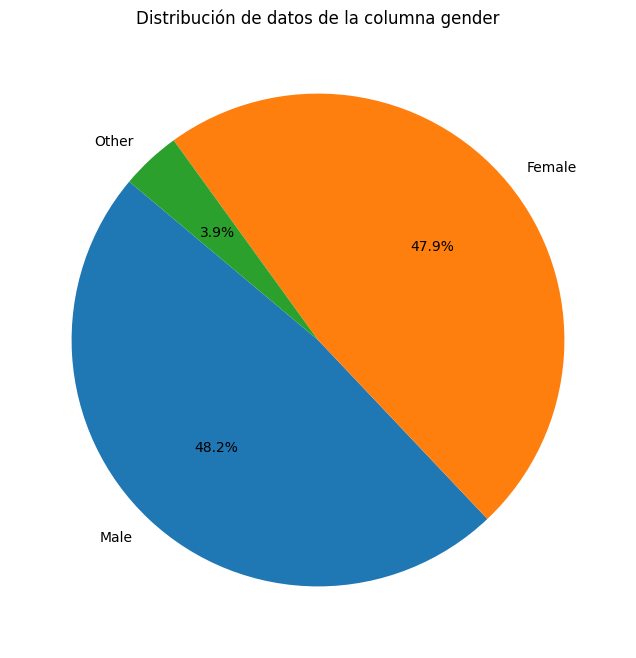

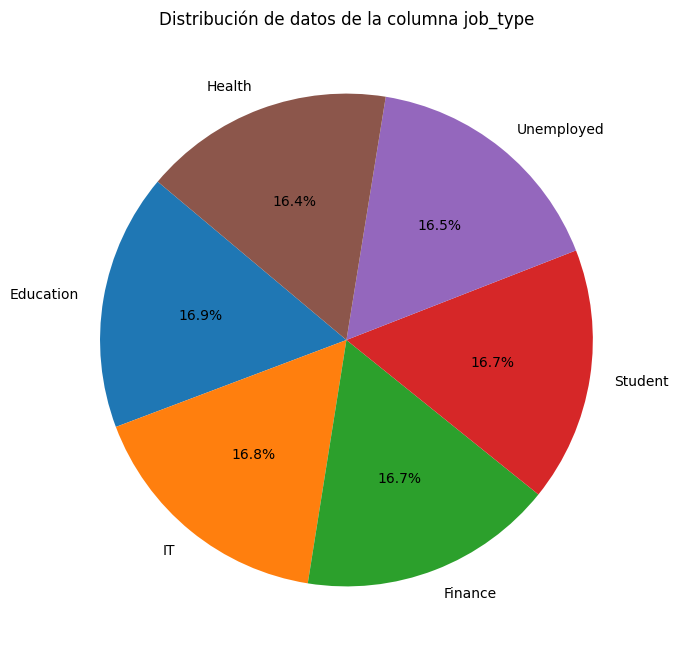

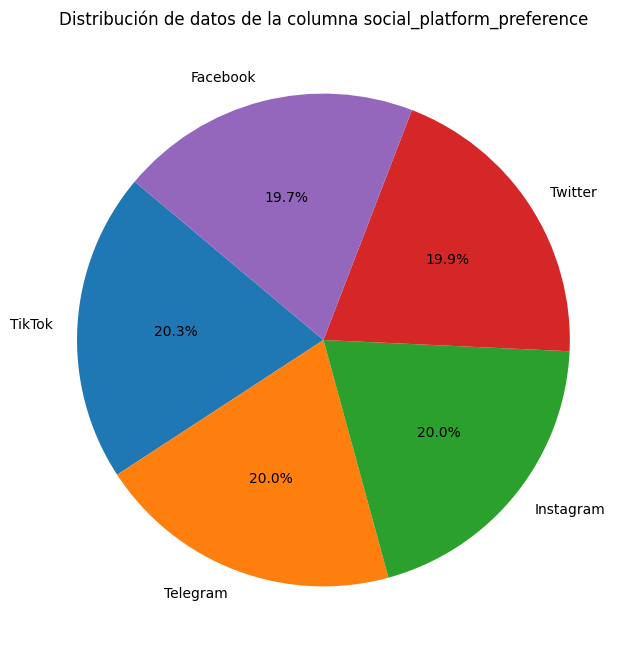

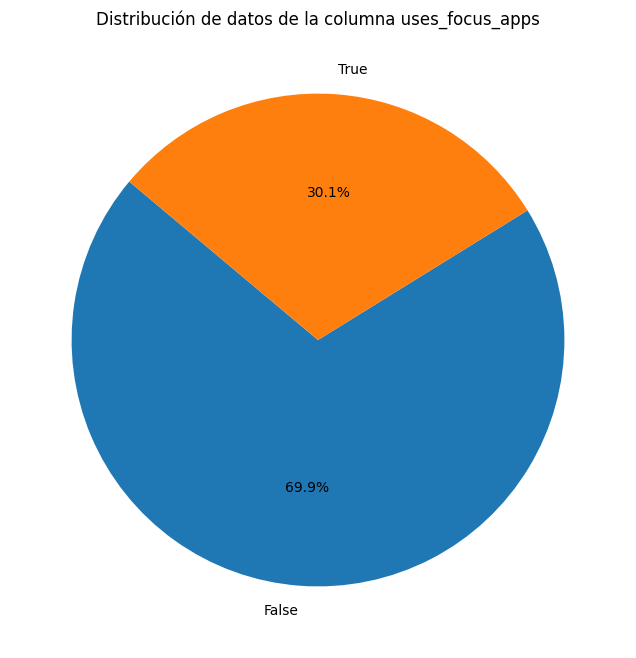

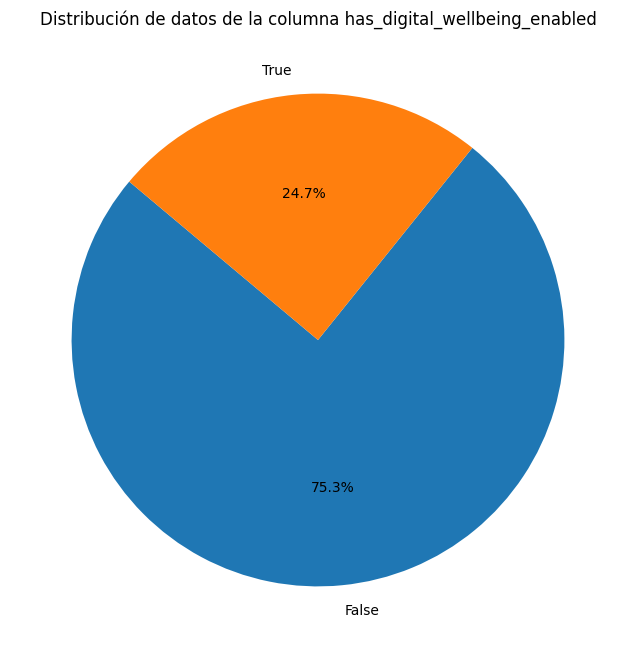

In [28]:
# Identificación variables categóricas
categorical_columns = df.select_dtypes(include=['object', 'bool']).columns

for col in categorical_columns:
    plt.figure(figsize=(8,8))
    plt.pie(df[col].value_counts(), labels=df[col].value_counts().index, autopct='%1.1f%%', startangle=140)
    plt.title('Distribución de datos de la columna ' + col)
    plt.show()

### Distribución variable numéricas

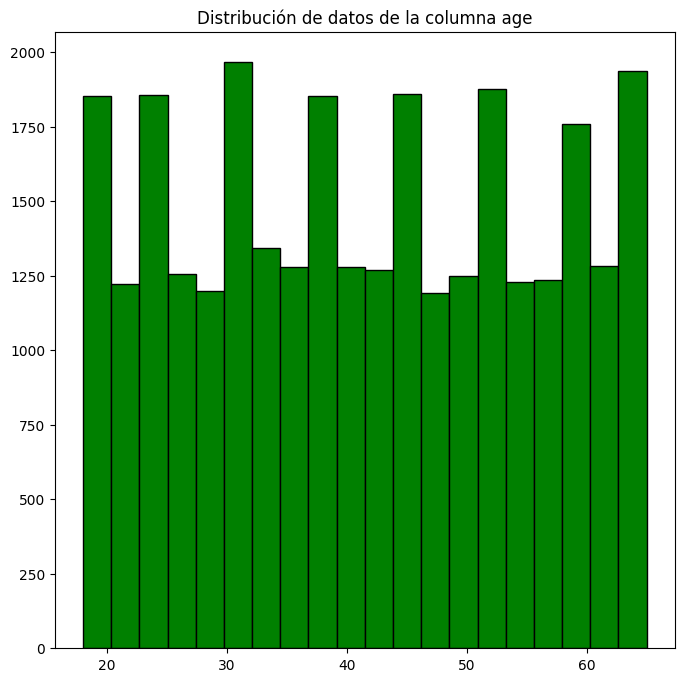

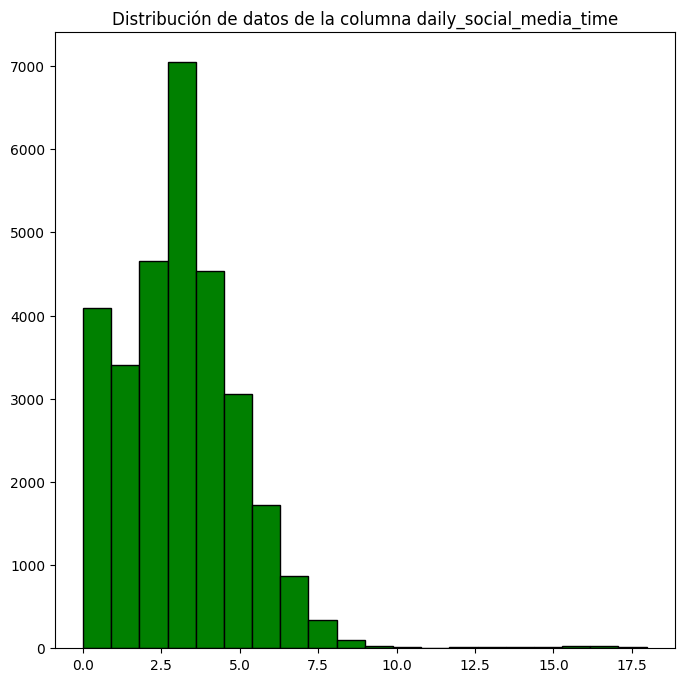

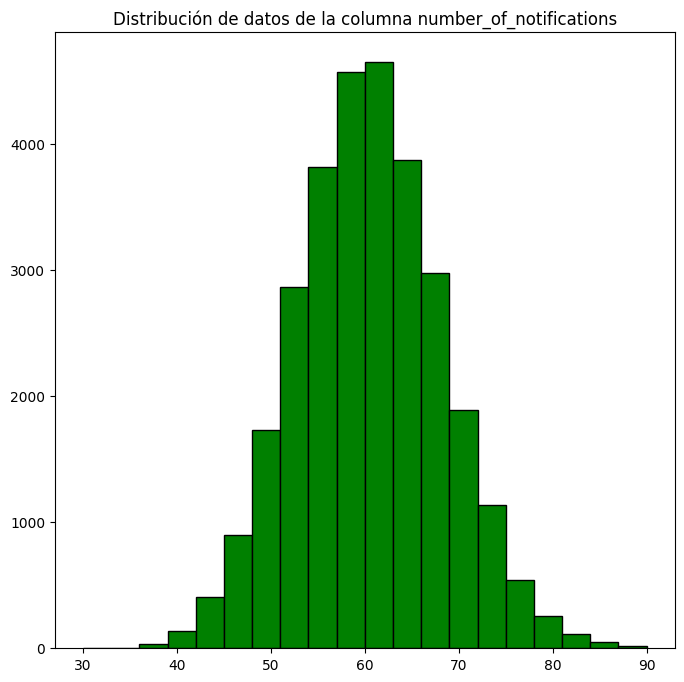

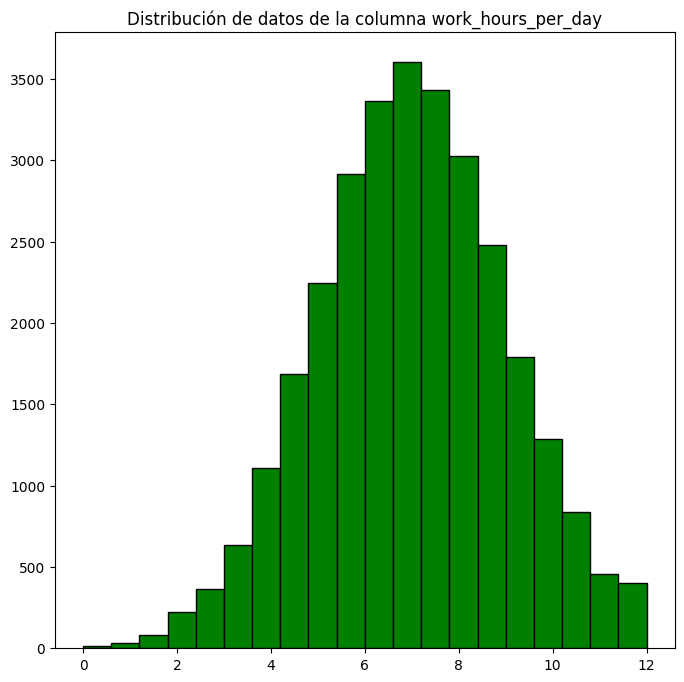

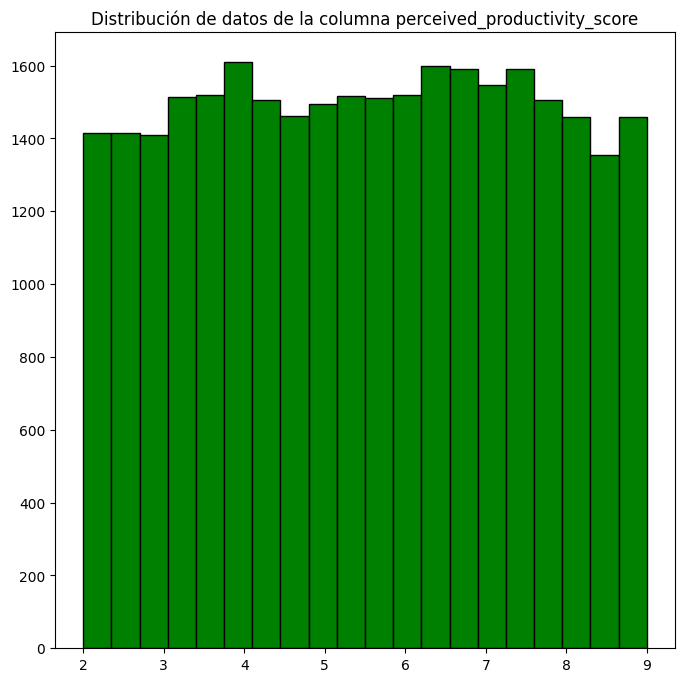

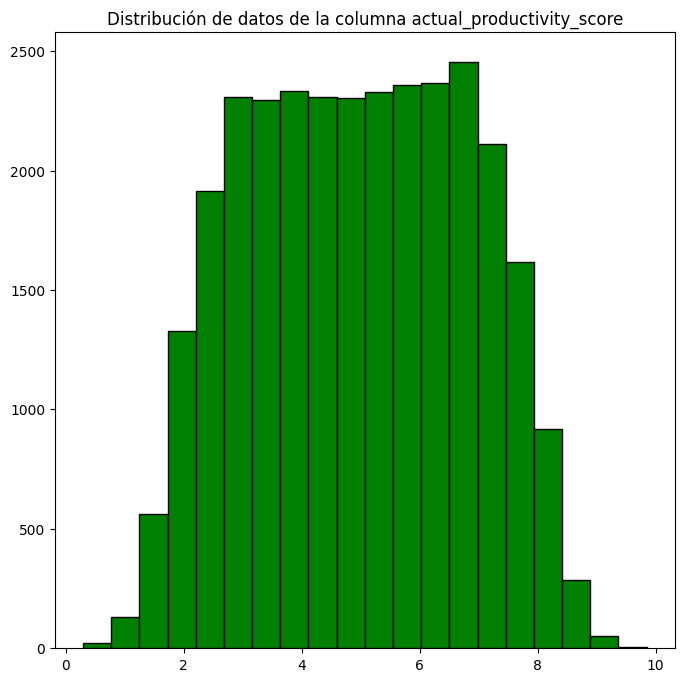

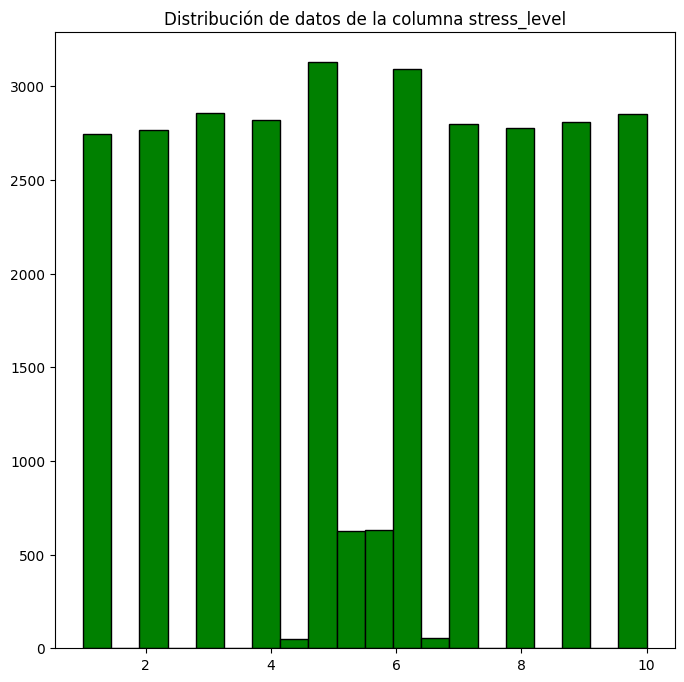

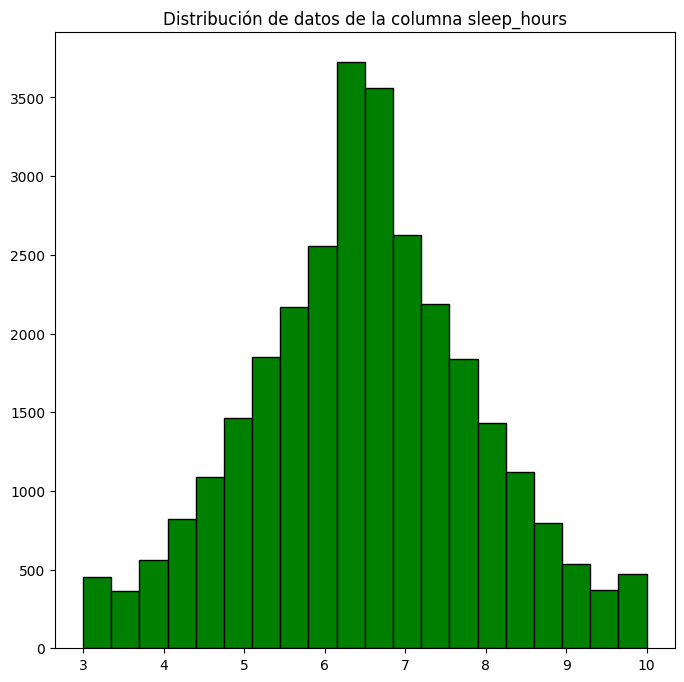

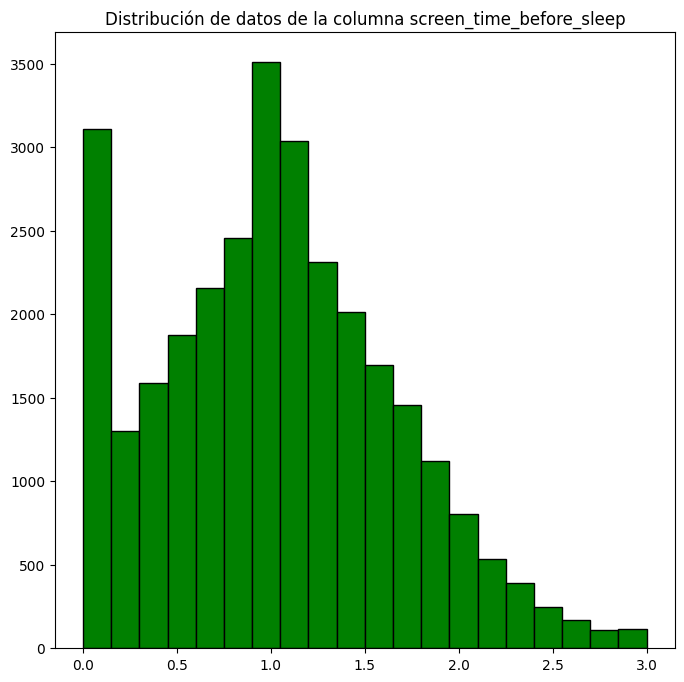

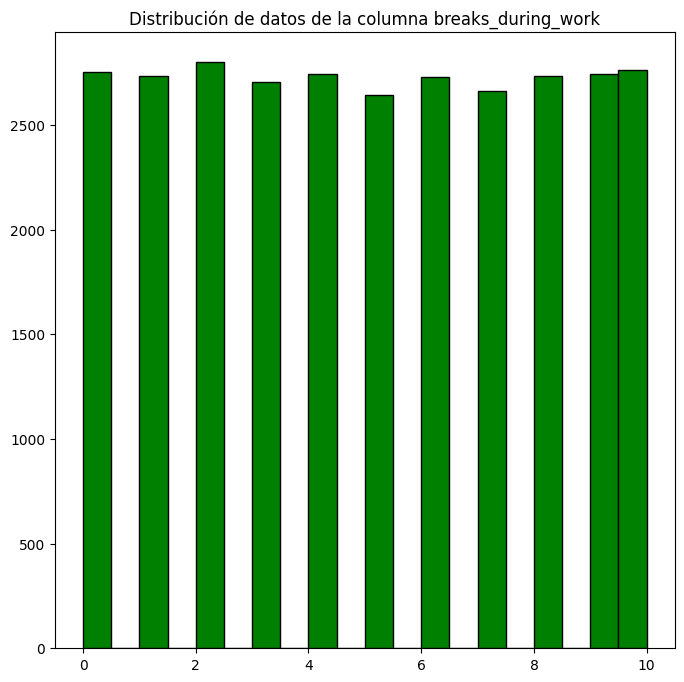

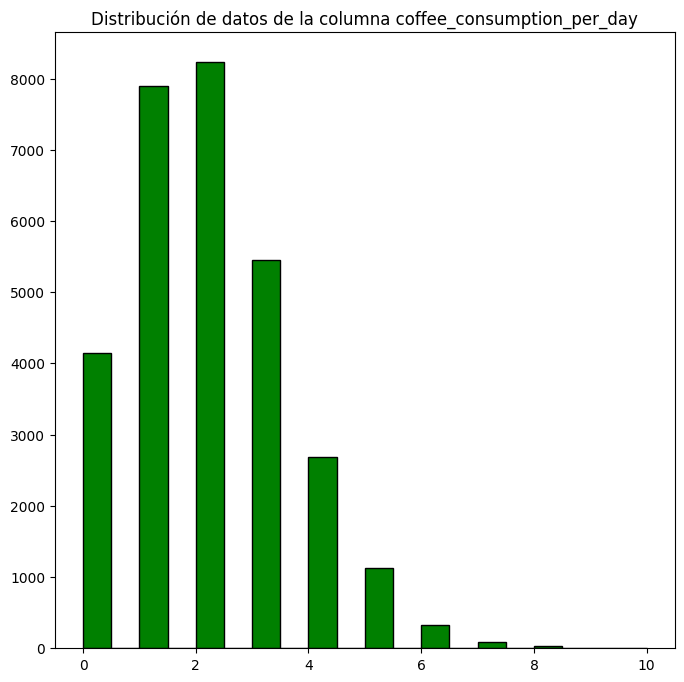

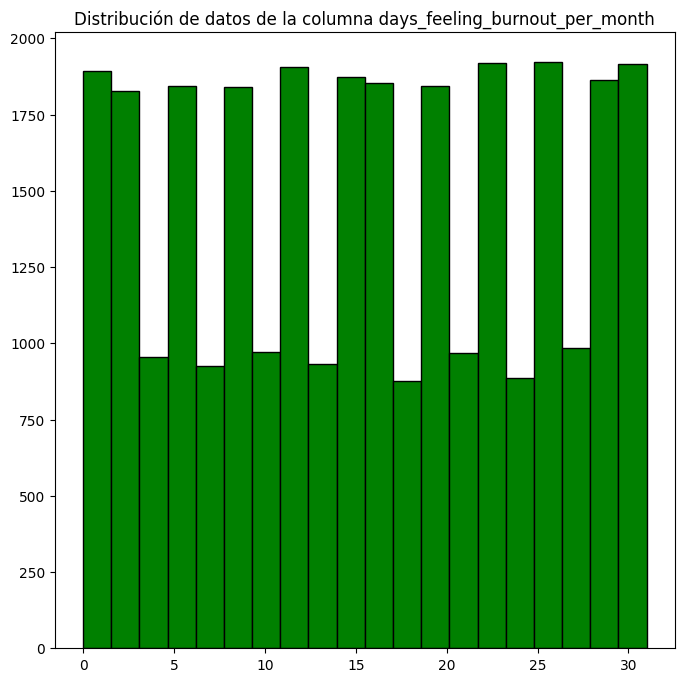

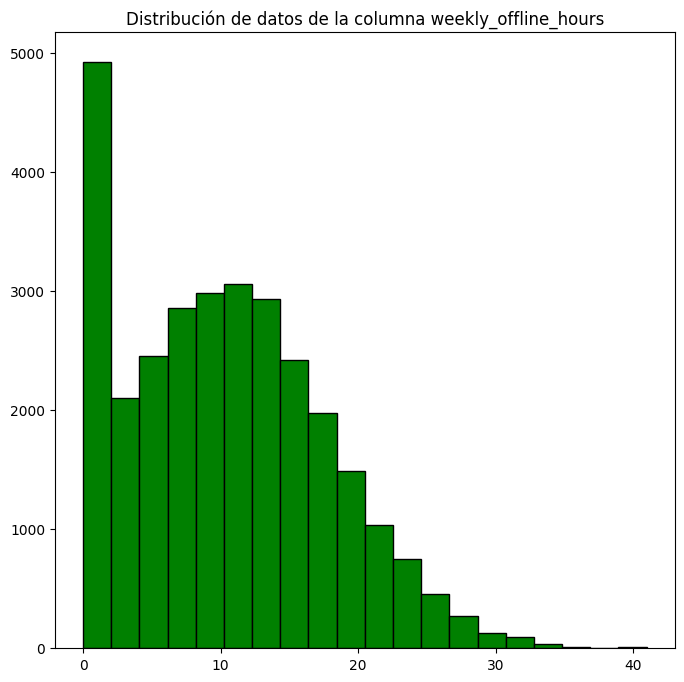

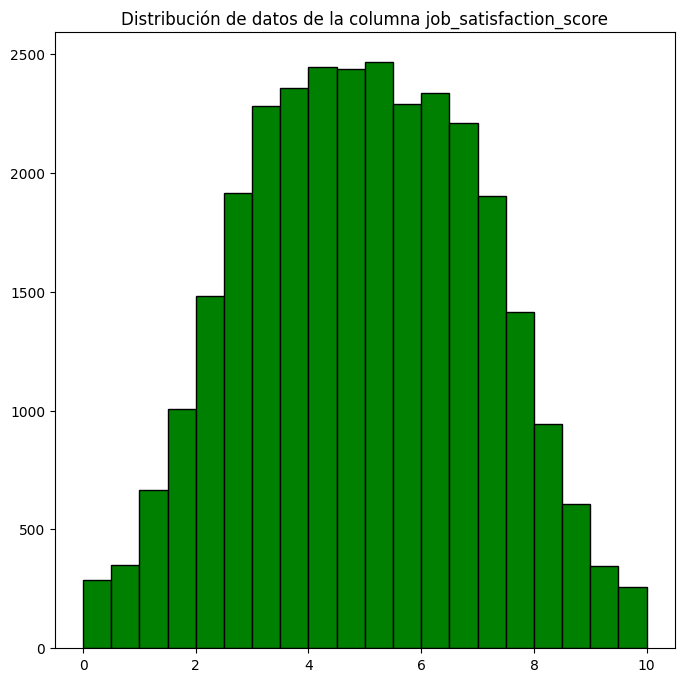

In [29]:
# Identificación variables numéricas
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    plt.figure(figsize=(8,8))
    plt.hist(df[col], bins=20, color='green', edgecolor='black')
    plt.title('Distribución de datos de la columna ' + col)
    plt.show()

### Conclusión distribución de datos
Podemos ver que las proporciones del dataset están equilibradas en sus columnas categóricas a excepción de las 2 columnas booleanas:
- uses_focus_apps (True 30.1% False 69.9%)
- has_digital_wellbeing_enabled (True 24.7% 75.3% False)

# H1: Los profesionales en sectores tecnológicos y de salud experimentan un impacto distinto en su productividad real ante la privación de sueño.

Para demostrar esto no basta con basarse en un promedio simple, por lo que se necesita verificar la tendencia. El propósito es descubrir si la productividad de un médico cae más rápido o más lento que la de un desarrollador de software cuando ambos empiezan a dormir mal

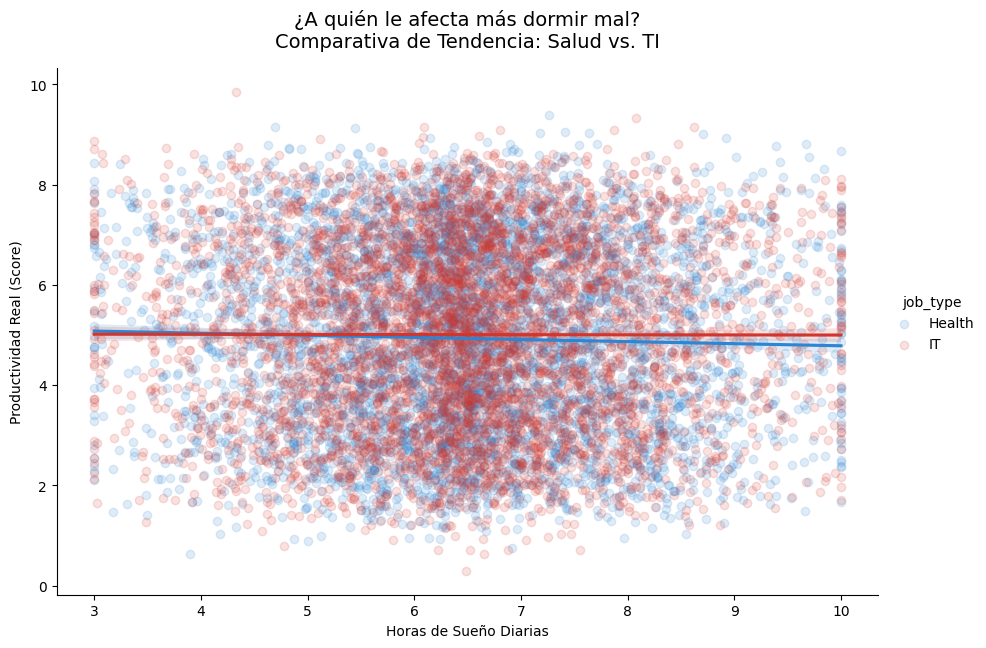

In [30]:
# Validando si la falta de sueño afecta de forma distinta a Salud vs. TI.


# 1. Filtrar el dataset para quedarnos solo con los dos grupos de interés
df_h1 = df_cleaned[df_cleaned['job_type'].isin(['Health', 'IT'])].copy()

# 2. Crear el gráfico de dispersión con líneas de regresión
g = sns.lmplot(
    data=df_h1, 
    x='sleep_hours', 
    y='actual_productivity_score', 
    hue='job_type', 
    palette=['#2E85D1', '#D1362E'], # Rojo para Salud, Azul para TI         Colores ['#1AA32E', '#4D96FF', '#F54927', '#000000']
    height=6, 
    aspect=1.5,
    scatter_kws={'alpha': 0.15} # Hacemos los puntos semi-transparentes por el volumen de datos
)

# 3. Personalizar títulos y etiquetas
g.set_xlabels('Horas de Sueño Diarias')
g.set_ylabels('Productividad Real (Score)')
plt.title('¿A quién le afecta más dormir mal?\nComparativa de Tendencia: Salud vs. TI', fontsize=14, pad=15)
plt.show()

### Tabla resumida de Productividad Promedio
Agrupamos por rangos de sueño para obtener números fríos.

In [31]:
# Entendiendo "Mal Sueño" como menos de 6 horas
df_h1['sleep_quality'] = df_h1['sleep_hours'].apply(lambda x: 'Privación de Sueño (<6h)' if x < 6 else 'Sueño Saludable (>=6h)')

resumen_h1 = df_h1.groupby(['job_type', 'sleep_quality'])['actual_productivity_score'].mean().unstack()
resumen_h1['Pérdida Real de Productividad'] = resumen_h1['Sueño Saludable (>=6h)'] - resumen_h1['Privación de Sueño (<6h)']
resumen_h1.round(2)

sleep_quality,Privación de Sueño (<6h),Sueño Saludable (>=6h),Pérdida Real de Productividad
job_type,,,
Health,4.95,4.92,-0.03
IT,5.00,5.01,0.02


Contrario a lo esperado, el análisis visual y de tendencias lineales revela que las horas de sueño no tienen un impacto significativo en la productividad real para los sectores de trabajo de Salud y TI. 
Para los trabajadores de TI podemos ver que que a mayor horas de sueño diarias, aumenta la productividad muy levemente, mientras que para trabajos de la salud a mayor horas de sueño hay una desmejoría en la productividad también levemente.
Por lo tanto, podemos decir que las pendientes de regresión se mantienen prácticamente planas (variaciones menores a 1 punto en la escala de productividad).

Nota de análisis: La relación entre el descanso y la productividad en este dataset parece no ser lineal o estar gobernada por el azar posiblemente por ser un dataset creado de forma sintética (mediante algoritmos), por lo que no podemos validar que un sector sea más vulnerable que el otro a la privación de sueño.

Profundizar en H1 para confirmar: Hacer un último intento con la hipótesis 1 usando un gráfico de cajas (sns.boxplot) agrupando el sueño en categorías estrictas: "Menos de 5 horas" vs "Más de 7 horas", para ver si en los extremos realmente hay un cambio o si todo sigue igual.

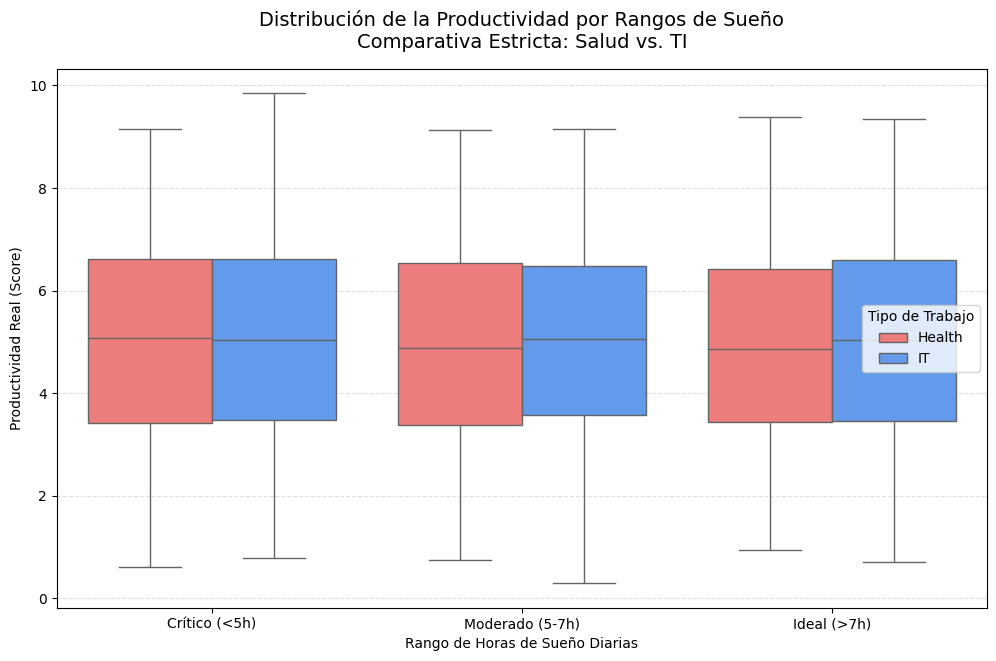

In [32]:
# ## Profundizando H1: Análisis No Lineal con Gráficos de Caja (Boxplot)
# Agrupamos las horas de sueño en categorías para evaluar si el impacto ocurre solo en escenarios de privación extrema.

# 1. Filtrar los datos para Salud y TI
df_h1_deep = df_cleaned[df_cleaned['job_type'].isin(['Health', 'IT'])].copy()

# 2. Crear categorías de sueño estrictas para capturar el comportamiento no lineal
condiciones = [
    (df_h1_deep['sleep_hours'] < 5),
    (df_h1_deep['sleep_hours'] >= 5) & (df_h1_deep['sleep_hours'] <= 7),
    (df_h1_deep['sleep_hours'] > 7)
]
opciones = ['Crítico (<5h)', 'Moderado (5-7h)', 'Ideal (>7h)']
df_h1_deep['sleep_range'] = np.select(condiciones, opciones, default='Moderado (5-7h)')

# Ordenar las categorías lógicamente para el gráfico
df_h1_deep['sleep_range'] = pd.Categorical(
    df_h1_deep['sleep_range'], 
    categories=['Crítico (<5h)', 'Moderado (5-7h)', 'Ideal (>7h)'], 
    ordered=True
)

# 3. Dibujar el Boxplot comparativo
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_h1_deep,
    x='sleep_range',
    y='actual_productivity_score',
    hue='job_type',
    palette=['#FF6B6B', '#4D96FF'],
    fliersize=1.5  # Controlar el tamaño de los puntos atípicos
)

# 4. Estética del gráfico
plt.title('Distribución de la Productividad por Rangos de Sueño\nComparativa Estricta: Salud vs. TI', fontsize=14, pad=15)
plt.xlabel('Rango de Horas de Sueño Diarias')
plt.ylabel('Productividad Real (Score)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Tipo de Trabajo')
plt.show()

Esto termina de hundir la Hipótesis 1. Al segmentar los extremos, confirmando que no existe absolutamente ninguna relación entre las horas de sueño y la productividad en este dataset.

Este comportamiento tan plano e idéntico en todas las cajas confirma al 100% que estamos ante un dataset sintético (generado por computadora) donde el creador no programó una correlación matemática entre el sueño y el rendimiento.

# Importante! : Paso importante omitido

Al tratarse de un dataset sintético, es útil realizar un analisis a la matriz de correlación, esto debió realizarse en el proceso EDA y ANTES de construir las hipótesis a validar, porque es muy probable que el dataset no refleje la realidad del mundo, por lo tanto una hipotesis puede ser válida, pero si la queremos contrarrestar contra los datos puede resultar negativa sin necesariamente ser así en la realidad.


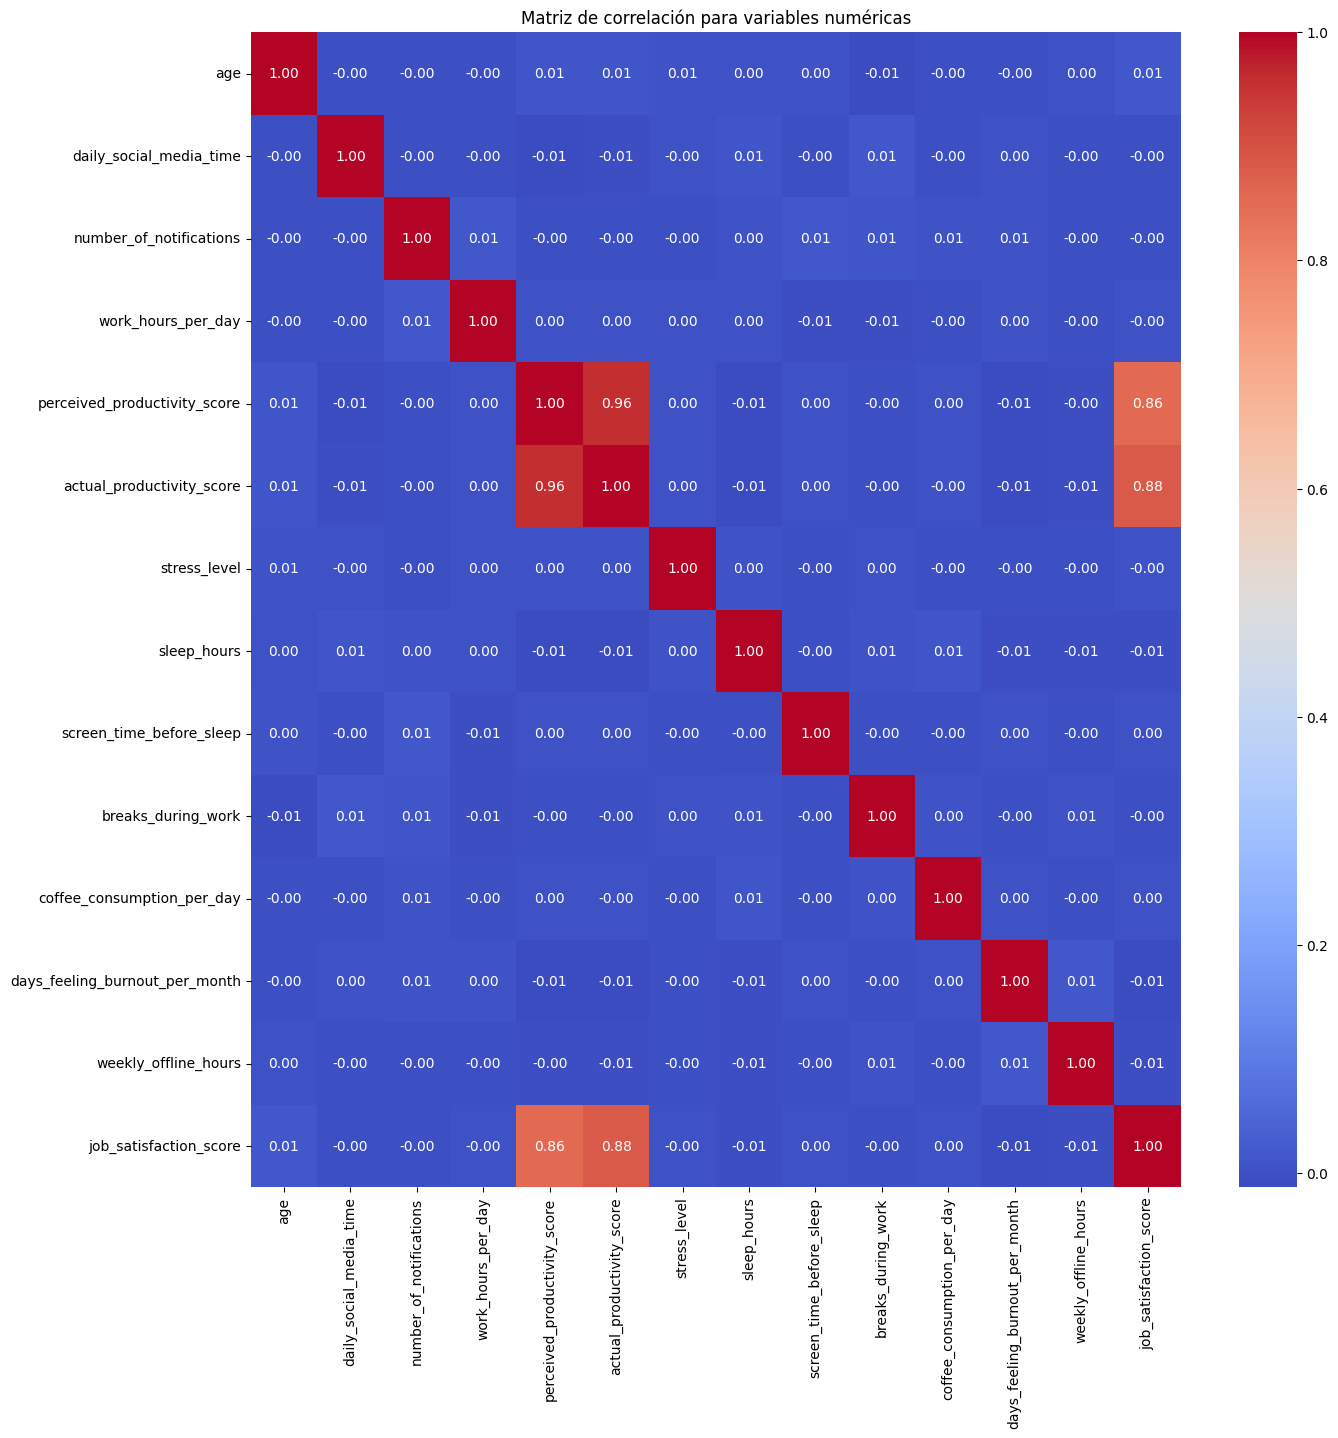

In [33]:
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Matriz de correlación para variables numéricas')
plt.show()

In [34]:
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr().abs()

high_corr = (
    corr_matrix.where(corr_matrix < 1)  # excluye diagonal
               .stack()
               .sort_values(ascending=False)
)

print('Correlaciones más fuertes: ', high_corr[high_corr > 0.8])

Correlaciones más fuertes:  actual_productivity_score     perceived_productivity_score    0.959700
perceived_productivity_score  actual_productivity_score       0.959700
job_satisfaction_score        actual_productivity_score       0.884714
actual_productivity_score     job_satisfaction_score          0.884714
perceived_productivity_score  job_satisfaction_score          0.856424
job_satisfaction_score        perceived_productivity_score    0.856424
dtype: float64


In [35]:
# df_encoded = pd.get_dummies(
#     df,
#     columns=[
#         'gender',
#         'job_type',
#         'social_platform_preference'
#     ],
#     drop_first=True
# )

# corr = df_encoded.corr()

# plt.figure(figsize=(20, 20))
# sns.heatmap(corr,
#             annot=True,
#             cmap='coolwarm',
#             fmt='.2f')

# plt.title('Matriz de correlación categóricas')
# plt.show()

In [36]:
# medir directamente la relación con la variable objetivo:
# (Esto mostrará qué variables están más asociadas con la satisfacción laboral)

# corr_target = (
#     df_encoded.corr()['job_satisfaction_score']
#     .sort_values(ascending=False)
# )

# print(corr_target.head(15))

In [37]:
# Visualización de las distintas matrices de correlación

# pearson_corr = df.select_dtypes(include=['int64','float64']).corr(method='pearson')

# spearman_corr = df.select_dtypes(include=['int64','float64']).corr(method='spearman')

# kendall_corr = df.select_dtypes(include=['int64','float64']).corr(method='kendall')

# for method, corr_matrix in zip(['Pearson', 'Spearman', 'Kendall'], [pearson_corr, spearman_corr, kendall_corr]):
#     plt.figure(figsize=(20, 20))
#     sns.heatmap(corr_matrix,
#                 annot=True,
#                 cmap='coolwarm',
#                 fmt='.2f')
#     plt.title(f'Matriz de correlación - {method}')
#     plt.show()

# Conclusiones:

Los pares de columnas que tienen correlación alta son:

- actual_productivity_score - perceived_productivity_score : 0.96
- job_satisfaction_score - perceived_productivity_score : 0.86
- job_satisfaction_score - actual_productivity_score: 0.88

En un contexto laboral de la vida real esto podría significar que: el empleado que siente que es productivo, efectivamente lo es, y esto le genera alta satisfacción.

Las relaciones a revisar sobre la matriz de correlación sobre las hipótesis H2 y H3 planteadas inicialmente:
- weekly_offline_hours vs stress_level (H2).
- breaks_during_work vs job_satisfaction_score (H3).

Lo que se puede analizar es que la correlación entre estas variables son de 0.00, lo que significa que, en este dataset, las hipótesis originales (H2 y H3) no tienen sustento en este dataset y por lo tanto no tiene sentido ahondar en ellas.

### Conclusión de aprendizaje:
Para posteriores prácticas, cada vez que se trabaje con un dataset de una fuente abierta como Kaggle, no está de más realizar la matriz de correlación independientemente si el dataset es de fuente sintética o no. Esto va ser un buen punto de partida antes de formular las hipótesis y evitar que se repita la situación vivida en este proyecto.